In [1]:
import tifffile
from scipy import ndimage
import read_roi
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
import seaborn as sns
from pandas.api.types import CategoricalDtype
import scipy as sp
import tkinter as tk
from tkinter import filedialog


In [2]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/2021-06-14_titrationINT_WT')

In [49]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if (str(i)[-2:] == 'nM') == True]
folders

[WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/2021-06-14_titrationINT_WT/CH4_typeWT_DCX025nM'),
 WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/2021-06-14_titrationINT_WT/CH5_typeWT_DCX015nM'),
 WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/2021-06-14_titrationINT_WT/CH6_typeWT_DCX005nM'),
 WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/2021-06-14_titrationINT_WT/CH7_typeWT_DCX002nM'),
 WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/2021-06-14_titrationINT_WT/CH8_typeWT_DCX001nM')]

In [50]:
dateloc = str(path).rfind("202")
date = str(path)[dateloc : dateloc+10]

DCX = 'DCX'
conc = 'Concentration ' r'$(\mu M)$'

ch = []
conc_DCX = []
DCX_type = []

for i in folders:
    CHloc = str(i).find("CH")
    DCXloc = str(i).rfind(DCX)
    dcxtype = str(i).find("type")
    ch = ch + [str(i)[CHloc+2:CHloc+3]]
    conc_DCX = conc_DCX + [(str(i)[DCXloc+3:DCXloc+6])]
    DCX_type = DCX_type + [(str(i)[dcxtype+4:DCXloc-1])]
    
date,ch, conc_DCX, DCX_type

('2021-06-14',
 ['4', '5', '6', '7', '8'],
 ['025', '015', '005', '002', '001'],
 ['WT', 'WT', 'WT', 'WT', 'WT'])

In [51]:
DCX_conc =  [float(i) for i in conc_DCX]
DCXconc = '[DCX] ' r'$(n M)$'
DCX_conc 

[25.0, 15.0, 5.0, 2.0, 1.0]

In [52]:
n = len(folders)
pre_df = {'Date': np.full((n), date),'CH': ch ,conc : conc_DCX,'Type': DCX_type}
df = pd.DataFrame(pre_df)
df

,Date,CH,Concentration $(\mu M)$,Type
0,2021-06-14,4,025,WT
1,2021-06-14,5,015,WT
2,2021-06-14,6,005,WT
3,2021-06-14,7,002,WT
4,2021-06-14,8,001,WT


In [53]:

image = tifffile.imread(folders[1]/'GFP600px.tif')
# Load line
roi = read_roi.read_roi_zip(folders[1]/'kymolines.zip')
roi1 = list(roi.values())[0]


In [54]:
def gettips(roi):
    tip_start = []
    tip_end = []
    
    for i in np.arange(len(roi)) :
        roii = list(roi.values())[i]
        tip_start = tip_start + [[roii['y1'], roii['x1']]]
        tip_end = tip_end + [[roii['y2'], roii['x2']]]
        
    return tip_start,tip_end
        

In [55]:
tip_start,tip_end = gettips(roi)

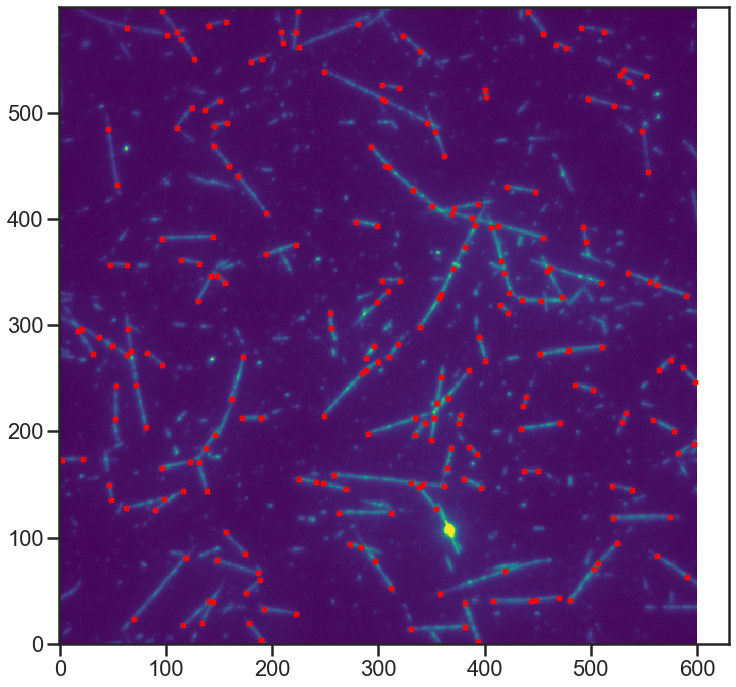

In [56]:
fig, ax = plt.subplots(figsize=(12, 12))

ax.imshow(image, interpolation='none', origin=[0, 0], cmap='viridis')
ax.set_aspect('equal')

for i in np.arange(len(roi)) :
    ax.scatter(tip_start[i][1], tip_start[i][0], color='red', s=20, marker="x")
    ax.scatter(tip_end[i][1], tip_end[i][0], color='red', s=20, marker="x")

In [57]:
def get_point_from_vector(vec, point, distance):
    """Given a vector get the coordinate of the point
    at a certain distance from the input point.

    Args:
      vec: array, vector.
      point: array, input point.
      distance: float, the distance.
    """
    vec = np.array(vec)
    point = np.array(point)
    norm = np.sqrt(np.sum(vec ** 2))
    return point + (vec / norm) * distance


def discretize_line(line, spacing):
    """Return a list points located at equidistance on the input line.

    The list will also include the input line points.

    Args:
      line: array, shape=2x2
      spacing: float, the distance between each points.

    """

    vec = line[1] - line[0]
    norm = np.sqrt(np.sum(vec ** 2))

    points = []

    distances = np.arange(0, np.round(norm), spacing)
    for d in distances:
        p = get_point_from_vector(vec, line[0], d)
        points.append(p)

    points.append(line[1])
    return np.array(points)

def get_normal_points(vec, points, distance):
    """From a vector and a list of points, get the point perpendicular
    to the vector at a specific distance from the input point.

    Args:
      vec: array, vector.
      points: array, input point (can be a single point
          or an array of points).
      distance: float.
    """
    vec = np.array(vec)
    points = np.array(points)

    norm = np.sqrt(np.sum(vec ** 2))

    # Get the normal vectors
    n1 = np.array([-vec[1], vec[0]])
    n2 = np.array([vec[1], -vec[0]])

    # Distance ratio
    t = distance / norm

    points1 = (1 - t) * points + t * (points + n1)
    points2 = (1 - t) * points + t * (points + n2)

    return np.array([points1.T, points2.T])

def get_thick_line(point1, point2, length_spacing=1, line_thickness=0, width_spacing=1):
    """Construct a list of points representing a discrete line. If `line_thickness` > 0 then
    the line is composed of multiple parallel line to each other with a width equal to
    `line_thickness`.

    Args:
      point1: 1D array or float.
      point2: 1D array or float.
      length_spacing: float, when computing the points inside a line
          what distance should separate the points (pixel).
      line_thickness: float, the thickness of the line used centered on
          the input line (pixel).
      width_spacing: float, same as `length_spacing` but in the  perpendicular
          direction when `line_thickness` is not 0.

    Returns:
      points: 3D array of shape [2xWxL] where W are points along the thickness of the line and L along its length.
    """

    line_tips = np.array([point1, point2])

    # Get points along the initial line.
    points = discretize_line(line_tips, length_spacing)

    if line_thickness > 0:

        # Get the two lines parallel to the initial line
        # at the distance defined by `line_thickness`.
        normal_distance = line_thickness / 2
        vec = points[-1] - points[0]
        normal_points = get_normal_points(vec, points, normal_distance)

        lines = []
        # Iterate over the length of the initial line.
        for p1, p2 in np.rollaxis(normal_points, -1):
            line = np.array([p1, p2])
            thickness_points = discretize_line(line, width_spacing)
            lines.append(thickness_points)
        lines = np.array(lines).T
    else:
        lines = np.array([points]).T.swapaxes(1, 2)

    return lines

def line_profile(
    image,
    point1,
    point2,
    length_spacing=0.1,
    line_thickness=0,
    width_spacing=0.1,
    normalized_intensities=True,
    threshold=None,
):
    """Get a line profile defined by an image and two points.

    Args:
      image: 2D array.
      point1: 1D array or float.
      point2: 1D array or float.
      length_spacing: float, when computing the points inside a line
          what distance should separate the points (pixel).
      line_thickness: float, the thickness of the line used centered on
          the input line (pixel).
      width_spacing: float, same as `length_spacing` but in the  perpendicular
          direction when `line_thickness` is not 0.
      normalized_intensities: bool, normalize from 0 to 1 if True.

    Returns:
      x_profile: array, the x coordinates of the profile where unit is pixel.
      y_profile: array, the intensities values of the profile.
    """

    lines = get_thick_line(
        point1,
        point2,
        length_spacing=length_spacing,
        line_thickness=line_thickness,
        width_spacing=width_spacing,
    )

    # Get the intensity profile of the lines.
    y_profiles = ndimage.map_coordinates(image, lines.reshape(2, -1), order=1, mode="constant")
    y_profiles = y_profiles.reshape(lines.shape[1:])

    # Get the mean profile
    y_profile = y_profiles.mean(axis=0)

    if normalized_intensities:
        # Normalize the profile between 0 and 1.
        # FUTURE: could be modified.
        y_profile = y_profile / y_profile.max()

    # Define the x values of the profile so the unit is a pixel.
    x_profile = np.arange(0, y_profile.shape[0]) * length_spacing

    if threshold:
        to_keep = y_profile > threshold
        y_profile = y_profile[to_keep]
        x_profile = x_profile[to_keep]

    return x_profile, y_profile

In [58]:
intensities = []

for i in np.arange(len(roi)) :
     
    line = line_profile(
        image,
        tip_start[i],
        tip_end[i],
        length_spacing=0.1,
        line_thickness=2,
        width_spacing=0.1,
        normalized_intensities=False,
        threshold=None )
    
    intensities = np.append(intensities,np.mean(line[1]))

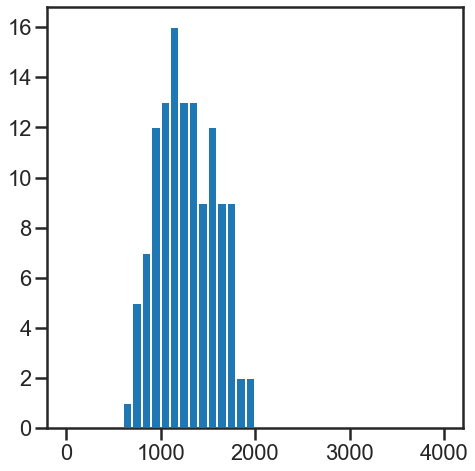

In [59]:
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(intensities, bins=np.arange(0, 4000 + 100, 100));

In [60]:
np.mean(intensities),np.std(intensities)

(1280.340800087497, 308.4627367070755)

In [61]:
def getintensities(path,image,kymolines):

    image = tifffile.imread(path/image)
    
    roi = read_roi.read_roi_zip(path/kymolines)
    
    tip_start,tip_end = gettips(roi)
    
    intensities = []

    for i in np.arange(len(roi)) :

        line = line_profile(
            image,
            tip_start[i],
            tip_end[i],
            length_spacing=0.1,
            line_thickness=2,
            width_spacing=0.1,
            normalized_intensities=False,
            threshold=None )

        intensities = np.append(intensities,np.mean(line[1]))
        
    return np.mean(intensities),np.std(intensities)
    

In [62]:
image = 'GFP600px.tif'
kymolines = 'kymolines.zip'
intensitiesmean = []
intensitiesstd = []

for i in folders:
    intensitiesmean0,intensitiesstd0 = getintensities(i,image,kymolines)
    intensitiesmean = intensitiesmean + [intensitiesmean0]
    intensitiesstd = intensitiesstd + [intensitiesstd0]

intensitiesmean, intensitiesstd

([1251.0880999053693,
  1280.340800087497,
  568.0184314292426,
  364.3932904648727,
  314.723517487485],
 [288.7741566010462,
  308.4627367070755,
  117.32012040892529,
  60.69387600252723,
  54.61292590782979])

In [63]:
df['Intensities Mean'] = intensitiesmean
df['Intensities STD'] = intensitiesstd
df

,Date,CH,Concentration $(\mu M)$,Type,Intensities Mean,Intensities STD
0,2021-06-14,4,025,WT,1251.088100,288.774157
1,2021-06-14,5,015,WT,1280.340800,308.462737
2,2021-06-14,6,005,WT,568.018431,117.320120
3,2021-06-14,7,002,WT,364.393290,60.693876
4,2021-06-14,8,001,WT,314.723517,54.612926


In [64]:
newdirectory = str(path.parents[0])+'//Data_Sheets_Int'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [65]:
df.to_csv(path/(date+'_intanalysis.csv'), encoding='utf-8', index=False)
df.to_csv(newmydir/(date+'_intanalysis.csv'), encoding='utf-8', index=False)

In [66]:
files = [x for x in newmydir.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if (str(i)[-3:] == 'csv') == True]
files

[WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/Data_Sheets_Int/2021-06-07_intanalysis.csv'),
 WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/Data_Sheets_Int/2021-06-10_intanalysis.csv'),
 WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/Intensities/Data_Sheets_Int/2021-06-14_intanalysis.csv')]

In [67]:
data = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    data = data.append(d, ignore_index=True)

data.to_csv(path/('MasterSheet.csv'), encoding='utf-8', index=False)

In [68]:
data

,Date,CH,Concentration $(\mu M)$,Type,Intensities Mean,Intensities STD
0,2021-06-07,3,200,WT,2392.011657,539.886015
1,2021-06-07,4,100,WT,1843.560254,427.726996
2,2021-06-07,5,50,WT,1300.100671,309.567417
3,2021-06-07,6,25,WT,1111.933466,294.623918
4,2021-06-07,7,15,WT,464.820376,92.058259
5,2021-06-10,2,200,WT,3075.668221,611.625825
6,2021-06-10,3,200,R303X,3154.303073,613.024696
7,2021-06-10,4,100,R303X,1326.095373,331.994459
8,2021-06-10,5,100,R303X,1238.015747,306.417835
9,2021-06-10,6,50,R303X,942.528321,219.773342


In [69]:
data['Type'].unique()[0]

'WT'

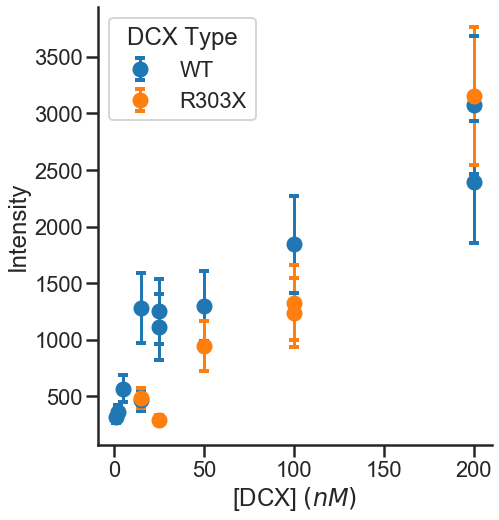

In [71]:
scattersize = 12
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
sns.set_style("ticks")

for i in data['Type'].unique():
    concentration =data[data['Type']==i][conc]
    meanint = data[data['Type']==i]['Intensities Mean']
    stdint = data[data['Type']==i]['Intensities STD']
    ax.errorbar(concentration, meanint , yerr= stdint , fmt='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,elinewidth=3)
    

ax.legend((['WT','R303X']),loc='upper left',title='DCX Type')
    
ax.set_xlabel(DCXconc)
ax.set_ylabel('Intensity')
#ax.set_xscale('log')
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()